# Block 02 - input data

The OpenSense 2025 training school's nowcasting session (Ritvanen & Imhoff,
`TrainingSchoolMergingApplication/nowcasting-session`) read 15-minute OpenRainER radar and
link maps for 17-19 August 2022 with a `load_opensense_dataset` helper and passed them to
pysteps on their native lat/lon grid. Here the same data come from the FieldSense readers
(`os_nowcasting.data`: the ARPAE-SIMC 15-min rain depth from the OpenRainER archive), on a
grid of square 2 km pixels in a local equirectangular projection, so pysteps gets a
projection in metres (`os_nowcasting.grid`).

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import viz_style as vs
from os_nowcasting import data, grid, nowcast, plots, products, verify
vs.use_style()

In [2]:
NET, STEP = "openrainer", 15
radar = data.radar(NET, "2022-08-18 05:45", "2022-08-18 11:00")
rate, meta = grid.to_pysteps(radar, STEP)
times = pd.DatetimeIndex(radar.time.values)
ISSUE = times.get_loc(pd.Timestamp("2022-08-18 08:45"))
print(rate.shape, "pixels of", meta["xpixelsize"] / 1000, "km; issue time", times[ISSUE])

(22, 97, 155) pixels of 2.0000659081611216 km; issue time 2022-08-18 08:45:00


In [3]:
from pprint import pprint
pprint({k: v for k, v in meta.items() if k != 'timestamps'})

{'accutime': 15.0,
 'cartesian_unit': 'm',
 'institution': 'FieldSense',
 'product': 'os_nowcasting',
 'projection': '+proj=eqc +lat_ts=44.372341 +lat_0=44.372341 +lon_0=10.950181 '
               '+ellps=sphere +R=6371008.8 +units=m',
 'threshold': 0.1,
 'transform': None,
 'unit': 'mm/h',
 'x1': -155005.10788248692,
 'x2': 155005.10788248692,
 'xpixelsize': 2000.0659081611216,
 'y1': -97003.1965458144,
 'y2': 97003.1965458144,
 'yorigin': 'lower',
 'ypixelsize': 2000.0659081611216,
 'zerovalue': 0.0,
 'zr_a': 200.0,
 'zr_b': 1.6}


## The products

The session nowcast the radar, PWS and link maps interpolated by IDW within 10, 20 and 40 km.
OpenRainER has no PWS; the study adds a radar field adjusted with the links (mergeplg
difference block kriging). Links: quality control and the nearby-link retrieval
(`os_nowcasting.products`).

124 links


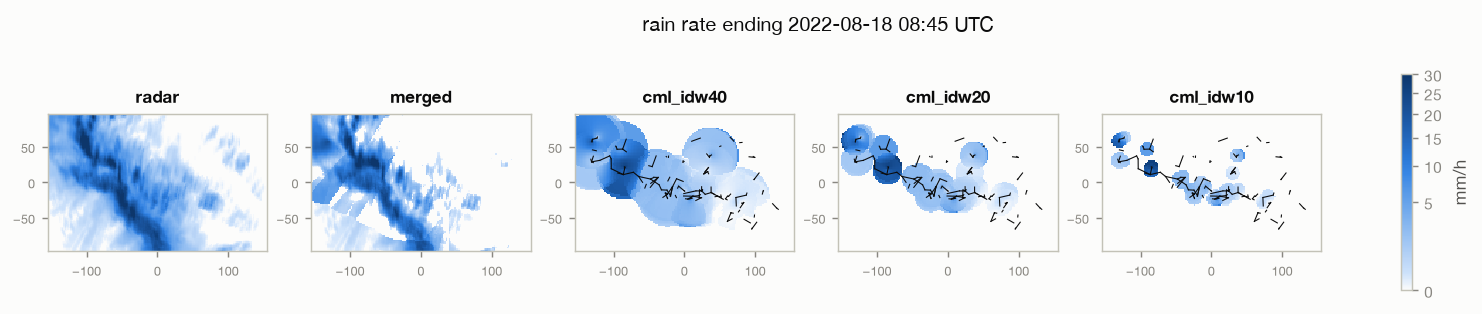

In [4]:
prods = products.build(NET, radar.time.values[0], radar.time.values[-1], radar)
links = prods.pop("_links")
print(links.sizes["link"], "links")
names = ["radar", "merged", "cml_idw40", "cml_idw20", "cml_idw10"]
fields = [grid.to_pysteps(prods[k], STEP)[0][ISSUE] for k in names]
fig, axes = plots.row(fields, names, meta, vmax=30)
from core.geo import to_local_xy
g = data.grid_for(NET)
x0, y0 = to_local_xy(links.site_0_lat.values, links.site_0_lon.values, g.lat.mean(), g.lon.mean())
x1, y1 = to_local_xy(links.site_1_lat.values, links.site_1_lon.values, g.lat.mean(), g.lon.mean())
for ax in axes[2:]:
    ax.plot(np.c_[x0, x1].T / 1000, np.c_[y0, y1].T / 1000, color="#0b0b0b", lw=0.6)
fig.suptitle(f"rain rate ending {times[ISSUE]:%Y-%m-%d %H:%M} UTC", fontsize=11);

## Distribution and transforms

Rain rates are bounded at zero and heavily skewed; optical flow and the cascade methods work
on the log-transformed field, dBR, with a 0.1 mm/h threshold and -15 dBR below it (the
session's choice). The normal-quantile transform is the alternative the session showed.

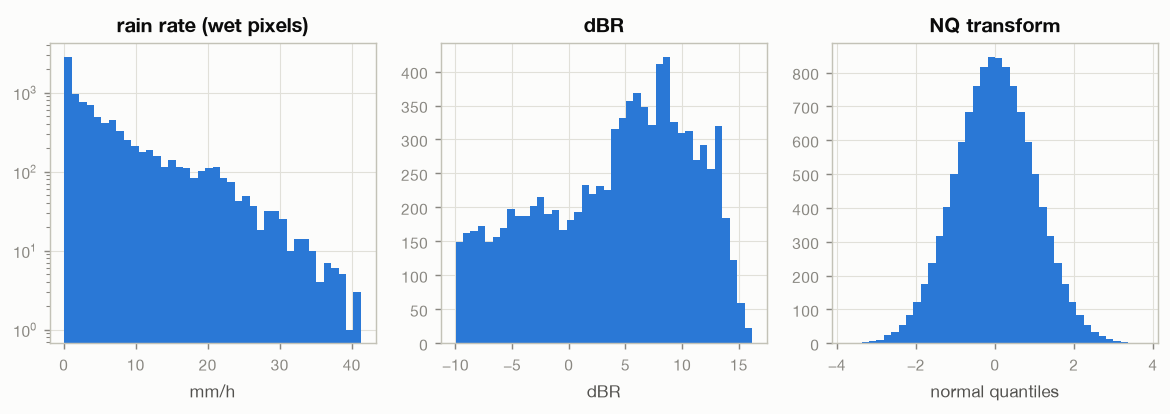

In [5]:
from pysteps.utils import transformation
dbr, meta_db = grid.to_dbr(rate, meta)
nq, _ = transformation.NQ_transform(rate[ISSUE][rate[ISSUE] > 0], meta)
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
axes[0].hist(rate[ISSUE][rate[ISSUE] > 0.1], bins=40, color="#2a78d6"); axes[0].set_yscale("log"); axes[0].set_xlabel("mm/h")
axes[1].hist(dbr[ISSUE][dbr[ISSUE] > -15], bins=40, color="#2a78d6"); axes[1].set_xlabel("dBR")
axes[2].hist(nq, bins=40, color="#2a78d6"); axes[2].set_xlabel("normal quantiles")
for ax, t in zip(axes, ["rain rate (wet pixels)", "dBR", "NQ transform"]):
    ax.set_title(t)

In [6]:
from pysteps.utils import conversion
dbz, _ = conversion.to_reflectivity(rate[ISSUE], meta)
print("reflectivity range", np.nanmin(dbz).round(1), "to", np.nanmax(dbz).round(1), "dBZ (Z = 200 R^1.6)")

reflectivity range 2.0 to 48.9 dBZ (Z = 200 R^1.6)
